In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import StandardScaler,MinMaxScaler,OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [20]:
df=pd.read_excel('glass.xlsx',sheet_name=1)

In [21]:
df.shape

(214, 10)

In [22]:
df.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB


In [24]:
##### Hence from the information, we can say that the dataset has numericl data with 9 float columns and 1 integer column

In [25]:
df.describe()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
count,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000
mean,1.518365,13.407850,2.684533,1.444907,72.650935,0.497056,8.956963,0.175047,0.057009,2.780374
std,0.003037,0.816604,1.442408,0.499270,0.774546,0.652192,1.423153,0.497219,0.097439,2.103739
min,1.511150,10.730000,0.000000,0.290000,69.810000,0.000000,5.430000,0.000000,0.000000,1.000000
25%,1.516522,12.907500,2.115000,1.190000,72.280000,0.122500,8.240000,0.000000,0.000000,1.000000
50%,1.517680,13.300000,3.480000,1.360000,72.790000,0.555000,8.600000,0.000000,0.000000,2.000000
75%,1.519157,13.825000,3.600000,1.630000,73.087500,0.610000,9.172500,0.000000,0.100000,3.000000
max,1.533930,17.380000,4.490000,3.500000,75.410000,6.210000,16.190000,3.150000,0.510000,7.000000


In [26]:
### Checking missing values
df.isnull().sum()

RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64

In [27]:
### Checking for duplicates
df.duplicated().sum()

np.int64(1)

In [30]:
### There is one duplictae present in the dataset, hence we can drop the duplicate value
df.drop_duplicates(inplace=True)

In [31]:
### Now ahain checking for duplicates are removed or not
df.duplicated().sum()

np.int64(0)

<Axes: >

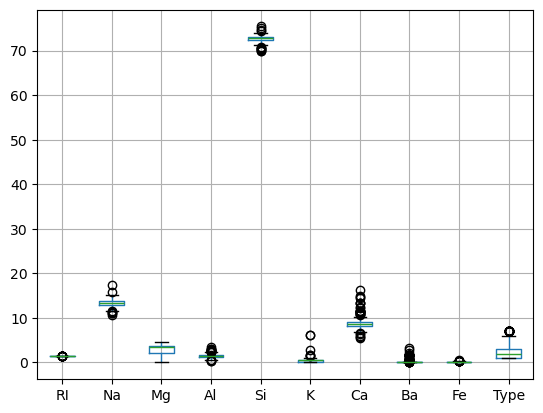

In [32]:
### Nextly checking for outliers
df.boxplot()

In [33]:
### Outliers are present in the given dataset, hence removing outliers using capping technique

In [34]:
def outlier_capping(df,column):

    Q1= df[column].quantile(0.25)

    Q3= df[column].quantile(0.75)

    IQR= Q3-Q1

    lower_extreme= Q1-1.5*IQR

    upper_extreme= Q3+1.5*IQR

    df[column]= df[column].apply(lambda x: lower_extreme if x<lower_extreme else upper_extreme if x>upper_extreme else x)

for col in df.select_dtypes(['int','float']).columns:

    outlier_capping(df,col)

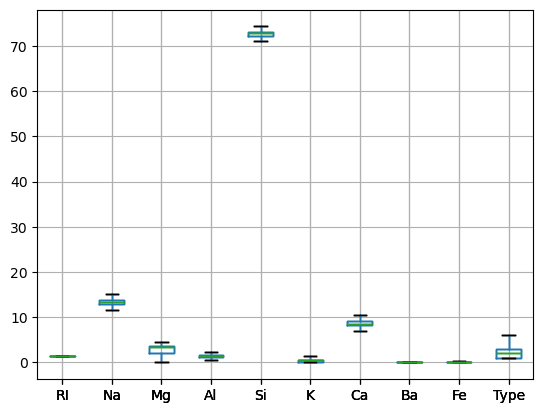

In [37]:
### Again plotting boxplot to check the outliers
df.boxplot()
plt.show()

In [39]:
### Checking the shape of the dataset after removal of outliers
df.shape

(213, 10)

In [40]:
### Checking the datatypes of columns
df.dtypes

RI      float64
Na      float64
Mg      float64
Al      float64
Si      float64
K       float64
Ca      float64
Ba      float64
Fe      float64
Type    float64
dtype: object

 #### 2.Data Visualization:
##### Create visualizations such as histograms, box plots, or pair plots to visualize the distributions and relationships between features. Analyze any patterns or correlations observed in the data.

In [45]:
### Finding the numerical columns and plotting the histogram
num_col=df.select_dtypes(include='float64').columns
num_col

Index(['RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe', 'Type'], dtype='object')

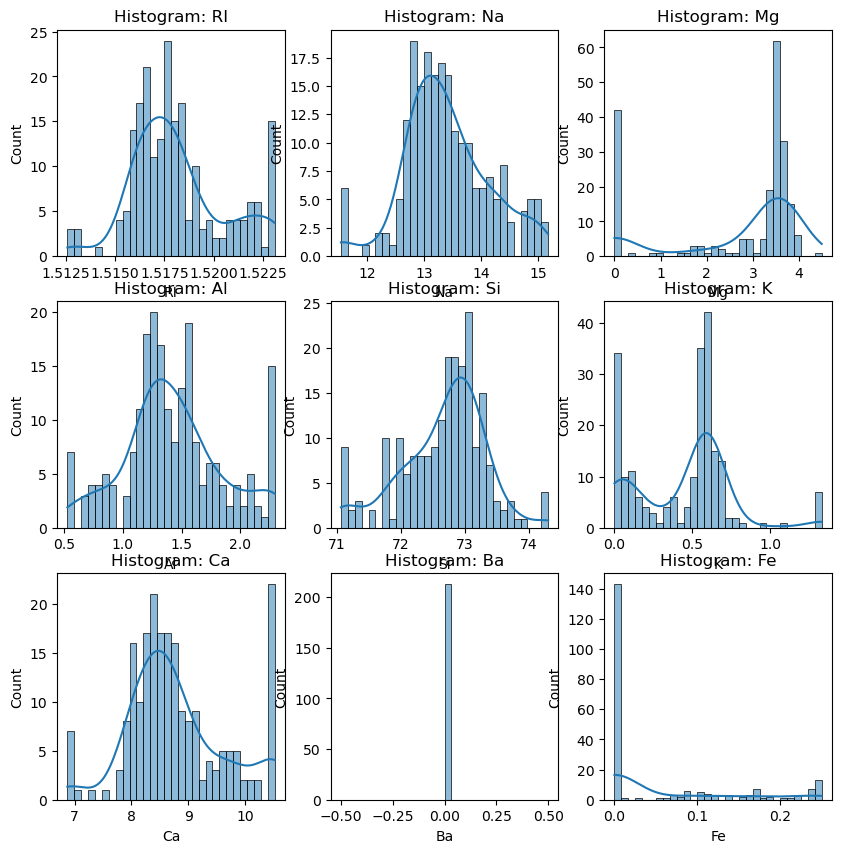

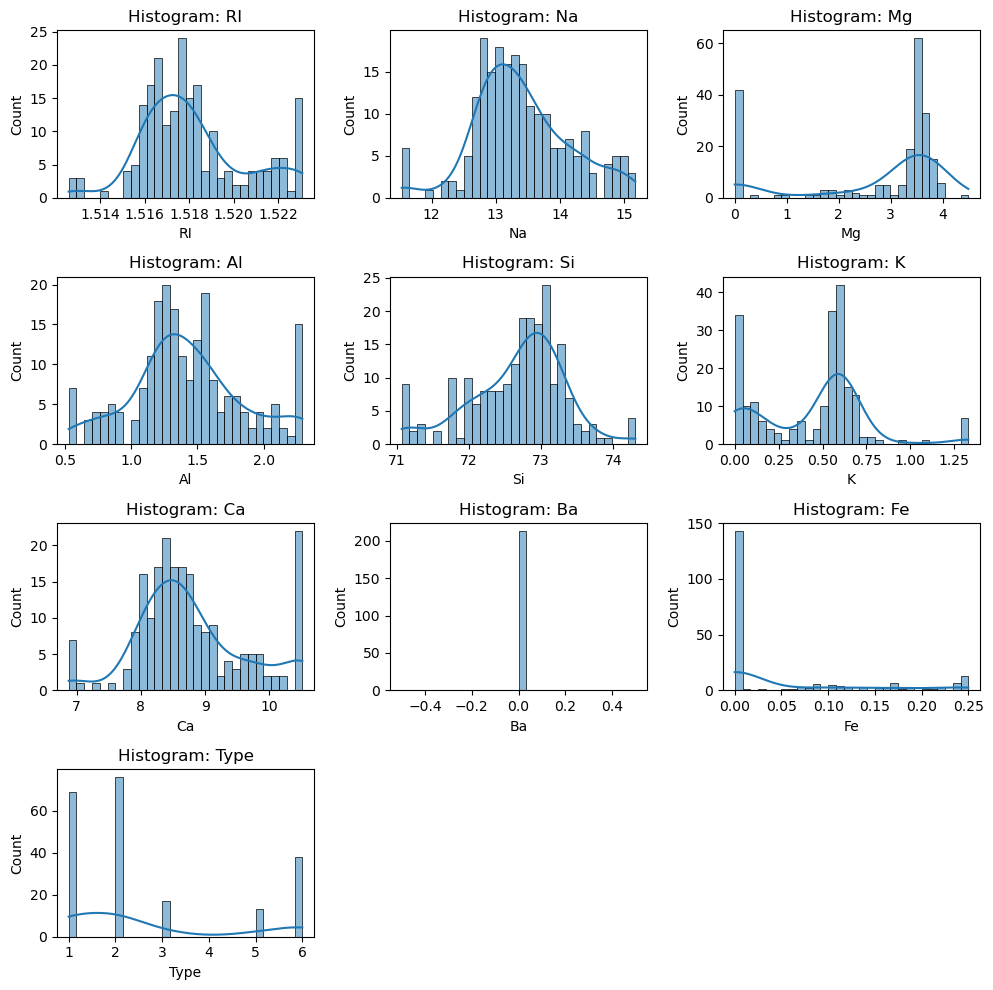

In [49]:
### plotting Histogram plot to see the feature distibution
plt.figure(figsize=(10,10))
for i, col in enumerate(num_col, 1):
    plt.subplot(4,3, i)
    sns.histplot(df[col], kde=True, bins=30) 
    plt.title(f"Histogram: {col}")
plt.tight_layout()
plt.show()

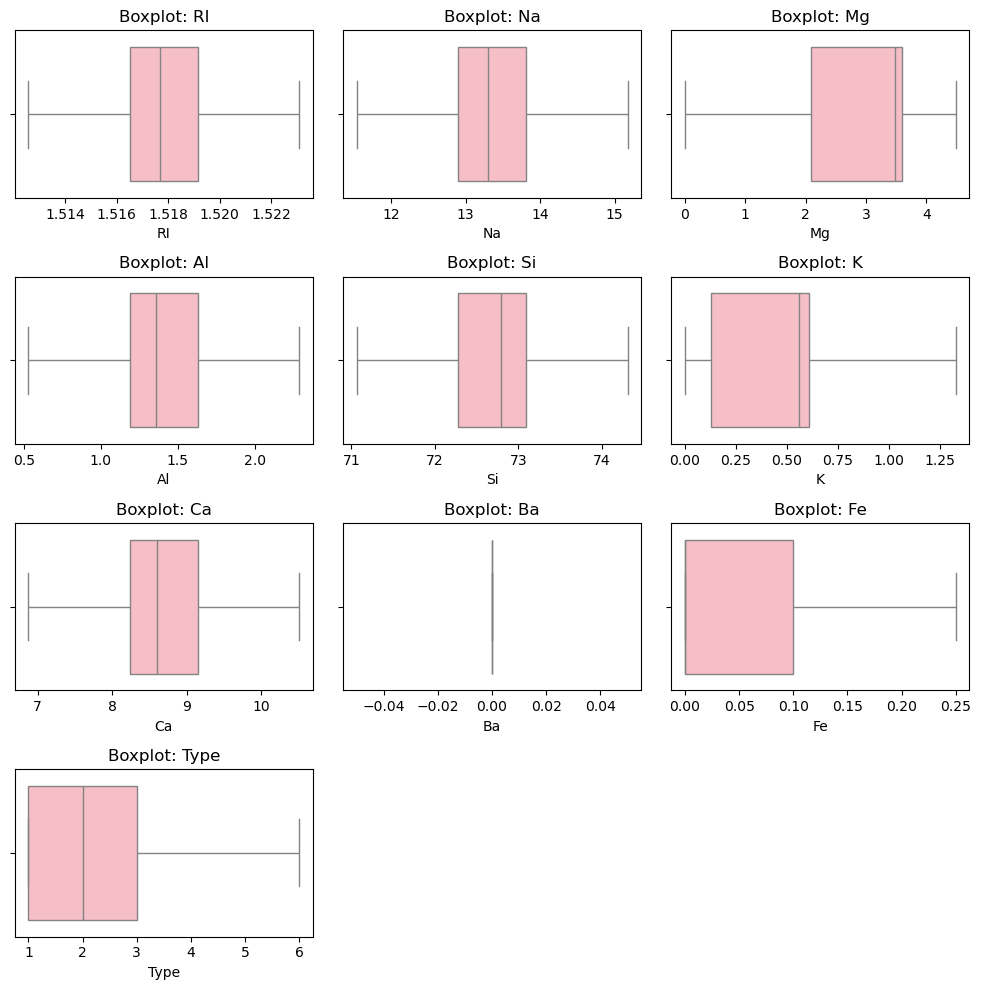

In [50]:
### Nextly plotting boxplot for all columns 
plt.figure(figsize=(10, 10))
for i, col in enumerate(num_col, 1):
    plt.subplot(4, 3, i)
    sns.boxplot(x=df[col], color="lightpink")  
    plt.title(f"Boxplot: {col}")
plt.tight_layout()
plt.show()

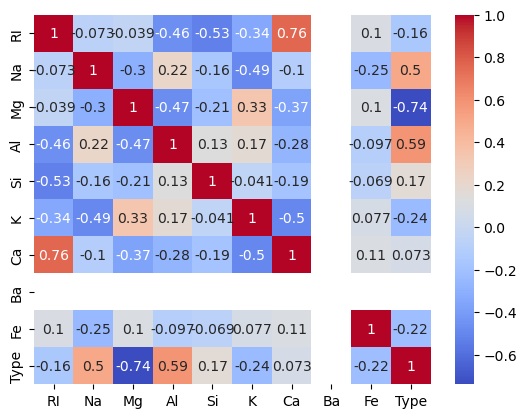

In [55]:
### Nextly plotting the heatmap to see correlation
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')
plt.show()

In [58]:
### Split the data into features and target
features=df.drop('Type',axis=1)
target=df['Type']

In [59]:
### Performed the data cleaning and removed the duplicates and checked for missing values as well
## there is no categorical data present in the dataset,hence encoding is not required
## Now applying scaling technique so the to bring the data in a particular range 

In [60]:
std_sca = StandardScaler()
scaled_data= std_sca.fit_transform(features)

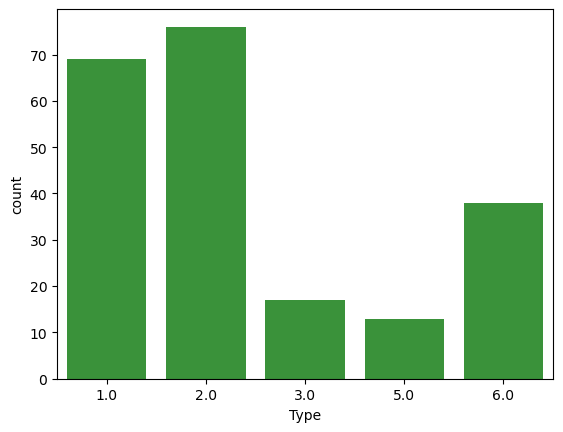

In [63]:
### checking for imbalances by plotting countplot
sns.countplot(x=target)
plt.show()

#### 4: Random Forest Model Implementation
##### Divide the data into train and test split.

In [70]:
x_train, x_test, y_train, y_test = train_test_split(scaled_data, target, test_size=0.2, random_state=42, stratify=target)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(170, 9)
(43, 9)
(170,)
(43,)


#### 2.Implement a Random Forest classifier using Python and a machine learning library like scikit-learn.

In [80]:
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, AdaBoostClassifier

 # training random forest model on training data 
rfc = RandomForestClassifier(n_estimators=50) 
rfc.fit(x_train, y_train)

RandomForestClassifier(n_estimators=50)

In [81]:
 #model makes predictions
y_pred = rfc.predict(x_test)

In [82]:
from sklearn.metrics import classification_report , confusion_matrix, f1_score, recall_score, precision_score, roc_curve,roc_auc_score 
#Calculating Recall Score
recall = recall_score(y_test, y_pred, average='weighted') 
print("Weighted Recall:", np.round(recall, 2))

 # Calculating precision
precision = precision_score(y_test, y_pred, average='weighted')
print("Weighted Precision:", np.round(precision, 2))

 # Calculate Weighted F1-score
f1 = f1_score(y_test, y_pred, average='weighted')
print("Weighted F1-score:", np.round(f1, 2))

 #For Cunfusion matrix
cm = confusion_matrix(y_test,y_pred)
cm

Weighted Recall: 0.84
Weighted Precision: 0.84
Weighted F1-score: 0.83


array([[13,  1,  0,  0,  0],
       [ 2, 11,  0,  1,  1],
       [ 1,  0,  2,  0,  0],
       [ 0,  0,  0,  3,  0],
       [ 0,  1,  0,  0,  7]])

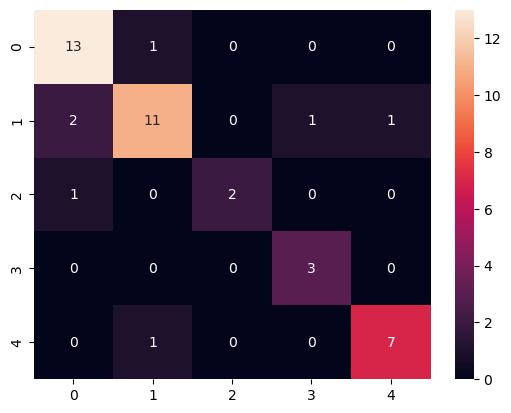

In [83]:
### plotting heatmap of confusion matrix
sns.heatmap(cm,annot=True)
plt.show()

##### 5: Bagging and Boosting Methods
###### Apply the Bagging and Boosting methods and compare the results.

#### Bagging Technique

In [91]:
bagging = BaggingClassifier(estimator=RandomForestClassifier(random_state=42), n_estimators=100, random_state=42) 
#training bagging model on training data
bagging.fit(x_train, y_train)

#bagging model makes predictions
y_pred_bag = bagging.predict(x_test) 

print("Bagging Accuracy:", accuracy_score(y_test, y_pred_bag)) 
print("Bagging F1-score:", f1_score(y_test, y_pred_bag, average='weighted'))
                            

Bagging Accuracy: 0.813953488372093
Bagging F1-score: 0.8118307467333366


#### Boosting Technique

In [92]:
boosting = AdaBoostClassifier( n_estimators=50, learning_rate=0.1, random_state=42)
#training adaboost model on training data
boosting.fit(x_train, y_train)

 #adaboost model makes predictions
y_pred_ada = boosting.predict(x_test)

print("Boosting Accuracy:", accuracy_score(y_test, y_pred_ada))
print("Boosting F1-score:", f1_score(y_test, y_pred_bag, average='weighted'))

Boosting Accuracy: 0.5813953488372093
Boosting F1-score: 0.8118307467333366


#### Comparing results

In [96]:
#### Performance metrics of Random Forest Classifier
raf_acc = accuracy_score(y_test, y_pred)
raf_prec = precision_score(y_test, y_pred,average='weighted')
raf_rec = recall_score(y_test, y_pred,average='weighted')
raf_f1 = f1_score(y_test, y_pred,average='weighted')
                       
### Performance metrics of Adaboost classifier
ada_acc = accuracy_score(y_test, y_pred_ada)
ada_prec = precision_score(y_test, y_pred_ada,average='weighted')
ada_rec = recall_score(y_test, y_pred_ada,average='weighted')
ada_f1 = f1_score(y_test, y_pred_ada,average='weighted') 

### Performance merics of Bagging Classifier
bag_acc = accuracy_score(y_test, y_pred_bag)
bag_prec = precision_score(y_test, y_pred_bag,average='weighted')
bag_rec = recall_score(y_test, y_pred_bag,average='weighted')
bag_f1 = f1_score(y_test, y_pred_bag,average='weighted')

In [106]:
#### Storing all results in the dictionary
results = {"Model": ["Random Forest", "AdaBoost", "Bagging Classifier"],
     "Accuracy": [raf_acc, ada_acc, bag_acc],
    "Precision": [raf_prec, ada_prec, bag_prec],
    "Recall": [raf_rec, ada_rec, bag_rec],
    "F1 Score": [raf_f1, ada_f1, bag_f1]}
print(results)

{'Model': ['Random Forest', 'AdaBoost', 'Bagging Classifier'], 'Accuracy': [0.6511627906976745, 0.5813953488372093, 0.813953488372093], 'Precision': [0.6159267089499647, 0.5127305890643784, 0.8231819859726835], 'Recall': [0.6511627906976745, 0.5813953488372093, 0.813953488372093], 'F1 Score': [0.6242589723617875, 0.5273115937847338, 0.8118307467333366]}


In [109]:
df1=pd.DataFrame(results)
df1

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.651163,0.615927,0.651163,0.624259
1,AdaBoost,0.581395,0.512731,0.581395,0.527312
2,Bagging Classifier,0.813953,0.823182,0.813953,0.811831


<Figure size 1000x500 with 0 Axes>

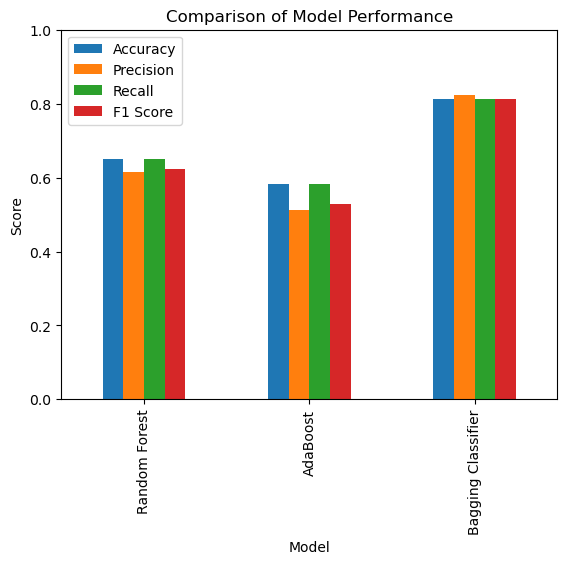

In [115]:
### Now seeing the results visually by plotting bar graphs
plt.figure(figsize=(10,5))
df1.set_index("Model").plot(kind='bar') 
plt.title("Comparison of Model Performance")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.show()

#### Questions
##### 1.Explain Bagging and Boosting methods. How is it different from each other.
##### Bagging
Bagging is an ensemble technique that builds multiple independent models (usually decision trees) on random subsets of the training data
and averages their predictions.
##### Key Points:
Reduces variance (overfitting).
Models are trained in parallel.
##### Most Common algorithm used is 
Random Forest.
Good when decision trees have high variance.
##### Boosting
Boosting is an ensemble method that builds models sequentially, each trying to correct the mistakes of the previous one.
##### Key Points:
Reduces bias and variance.
Models are trained sequentially.
###### Most Common algorithms:
AdaBoost (Adaptive Boosting)
Gradient Boosting
XGBoost, LightGBM

### 2. Explain how to handle imbalance in the data.
###### 1. Resampling Methods
a) Oversampling the Minority Class
Duplicate or generate new minority samples.
Popular method: SMOTE (Synthetic Minority Over-sampling Technique)
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

b) Undersampling the Majority Class
Randomly remove samples from the majority class.
from imblearn.under_sampling import RandomUnderSampler
rus = RandomUnderSampler(random_state=42)
X_resampled, y_resampled = rus.fit_resample(X_train, y_train)

##### 2. Using Class Weights
Tell the algorithm to give more importance to minority classes.
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(class_weight='balanced')
model.fit(X_train, y_train)

##### 3. Anomaly Detection Models
If the minority class is extremely rare (like fraud detection), treat it as an anomaly detection problem using:
Isolation Forest
One-Class SVM

##### 4. Evaluation Metrics
Avoid using accuracy alone—it can be misleading.
Use metrics better suited for imbalanced data:
Precision, Recall
F1-Score
ROC-AUC Score
Confusion Matrix
from sklearn.metrics import classification_report, roc_auc_score
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))